In [ ]:
from typing_extensions import TypedDict, Literal
from typing import List
from langgraph.types import Command
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel

llm = init_chat_model("openai:gpt-5-nano")

dumb_llm = init_chat_model("openai:gpt-3.5-turbo")
average_llm = init_chat_model("openai:gpt-4o")
smart_llm = init_chat_model("openai:gpt-5.4")

In [2]:
class State(TypedDict):

    question: str
    difficulty: str
    answer: str
    model_used: str


class DifficultyResponse(BaseModel):

    difficulty_level: Literal["easy", "medium", "hard"]

In [3]:
def dumb_node(state: State):
    response = dumb_llm.invoke(state["question"])
    return {
        "answer": response.content,
        "model_used": "gpt-3.5",
    }


def average_node(state: State):
    response = average_llm.invoke(state["question"])
    return {
        "answer": response.content,
        "model_used": "gpt-4o",
    }


def smart_node(state: State):
    response = smart_llm.invoke(state["question"])
    return {
        "answer": response.content,
        "model_used": "gpt-5.4",
    }


def assess_difficulty(state: State):
    structured_llm = llm.with_structured_output(DifficultyResponse)

    response = structured_llm.invoke(
        f"""
        다음 질문의 난이도를 평가하세요.
        질문: {state["question"]}

        - EASY: 단순한 사실, 기초적인 정의, 예/아니오로 답할 수 있는 질문
        - MEDIUM: 설명, 비교, 분석이 필요한 질문
        - HARD: 복잡한 추론, 다단계 과정, 심도 있는 전문 지식이 필요한 질문
        """
    )

    difficulty_level = response.difficulty_level

    if difficulty_level == "easy":
        goto = "dumb_node"
    elif difficulty_level == "medium":
        goto = "average_node"
    elif difficulty_level == "hard":
        goto = "smart_node"

    return Command(
        goto=goto,
        update={"difficulty": difficulty_level},
    )

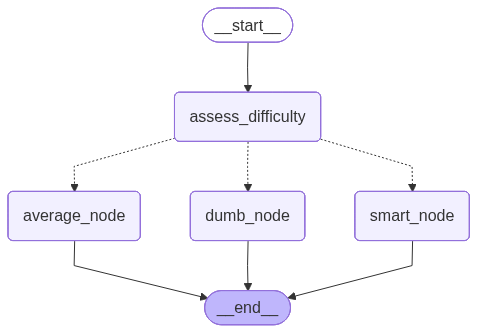

In [4]:
graph_builder = StateGraph(State)

graph_builder.add_node("dumb_node", dumb_node)
graph_builder.add_node("average_node", average_node)
graph_builder.add_node("smart_node", smart_node)
graph_builder.add_node(
    "assess_difficulty",
    assess_difficulty,
    destinations=(
        "dumb_node",
        "average_node",
        "smart_node",
    ),  # only for looks (no edges)
)

graph_builder.add_edge(
    START,
    "assess_difficulty",
)
graph_builder.add_edge("dumb_node", END)
graph_builder.add_edge("average_node", END)
graph_builder.add_edge("smart_node", END)

graph = graph_builder.compile()

graph

In [5]:
graph.invoke({"question": "Capital of Korea"})

{'question': 'Capital of Korea',
 'difficulty': 'medium',
 'answer': "The capital of South Korea is Seoul. North Korea's capital is Pyongyang. If you have a specific context in mind, feel free to ask!",
 'model_used': 'gpt-4o'}

In [6]:
graph.invoke({"question": "Investment potential of Uranium in 2026"})

{'question': 'Investment potential of Uranium in 2026',
 'difficulty': 'hard',
 'answer': 'Uranium in 2026 could have **meaningful upside**, but it’s a **high-volatility, policy-sensitive commodity investment**.\n\n## Bull case\n- **Rising nuclear support**: More countries are extending reactor lifespans and planning new builds for energy security and decarbonization.\n- **Supply constraints**: Uranium supply has been tight due to years of underinvestment, mine disruptions, and slow project restarts.\n- **Long-term contracting cycle**: Utilities may continue locking in future supply, which can support prices beyond spot-market swings.\n- **AI/data center power demand narrative**: Growing electricity demand may strengthen the case for stable baseload power like nuclear.\n\n## Bear case\n- **Project delays**: Nuclear plant approvals and construction often take years, so demand growth may arrive slower than expected.\n- **Price volatility**: Uranium markets are relatively small and can mo